# Fase 2- Dataset: performance no basquetebol universitário NCAA

O sucesso no basquetebol universitário na NCAA advém do equilíbrio entre a eficiência ofensiva e a defesa rigorosa. O diagrama de dispersão apresentado abaixo mostra que existe uma correlação visível entre estas métricas e a presença na Postseason. As equipas qualificadas para a Postseason concentram-se predominantemente no quadrante de alta eficiência em ambos os domínios. Esta evidência visual fundamenta a formulação deste problema como uma classificação binária, onde o objetivo é prever a probabilidade de qualificação com base no perfil estatístico das equipas. Contudo, o desafio real reside em garantir que o modelo aprende padrões universais e não apenas 'decora' épocas passadas, evitando o otimismo artificial.

### Importar bibliotecas

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### Pré-processamento

In [2]:
# carregar ficheiro csv
basquetebol = pd.read_csv("basket.csv")


In [3]:
#colunas do ficheiro
basquetebol.keys()

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')

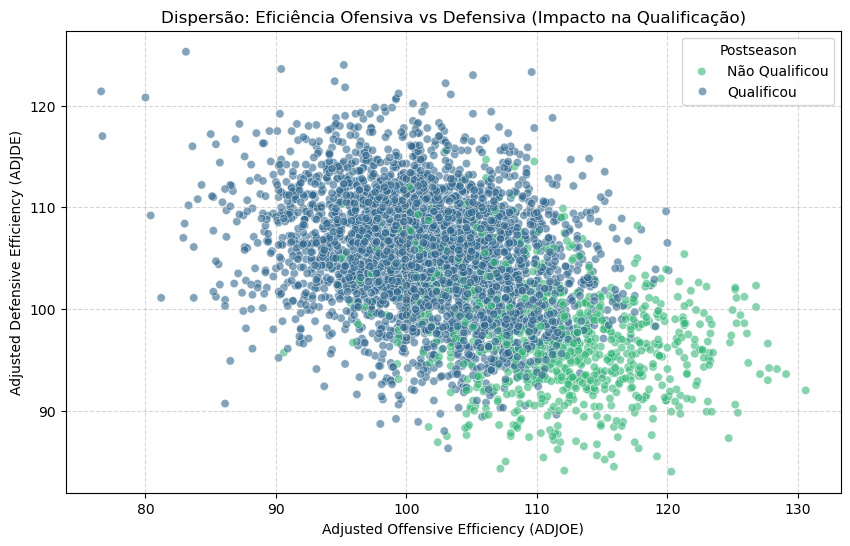

In [4]:
basquetebol['target'] = basquetebol['POSTSEASON'].fillna('N/A').apply(lambda x: 0 if x == 'N/A' else 1)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=basquetebol, x='ADJOE', y='ADJDE', hue='target', alpha=0.6, palette='viridis')

plt.title('Dispersão: Eficiência Ofensiva vs Defensiva (Impacto na Qualificação)')
plt.xlabel('Adjusted Offensive Efficiency (ADJOE)')
plt.ylabel('Adjusted Defensive Efficiency (ADJDE)')
plt.legend(title='Postseason', labels=['Não Qualificou', 'Qualificou'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
# Dicionário de tradução para nomes legíveis
nomes = {
    'WAB': 'Vitórias Acima da Bolha (WAB)',
    'W': 'Total de Vitórias',
    'ADJDE': 'Eficiência Defensiva Ajustada',
    'EFG_O': 'Percentagem Eficaz de Lançamentos (Ataque)',
    'FTR': 'Taxa de Lances Livres (Ataque)',
    '3P_O': 'Percentagem de Lançamentos de 3 pts (Ataque)',
    '2P_D': 'Percentagem de Lançamentos de 2 pts (Defesa)',
    'DRB': 'Taxa de Ressaltos Defensivos',
    'ORB': 'Taxa de Ressaltos Ofensivos',
    'TORD': 'Taxa de Turnovers Forçados (Defesa)',
    'FTRD': 'Taxa de Lances Livres Concedidos (Defesa)',
    'TOR': 'Taxa de Turnovers Cometidos (Ataque)',
    'ADJOE': 'Eficiência Ofensiva Ajustada',
    'G': 'Número de Jogos Realizados',
    '2P_O': 'Percentagem de Lançamentos de 2 pts (Ataque)',
    'BARTHAG': 'Poder da Equipa (Power Rating)',
    'EFG_D': 'Percentagem Eficaz de Lançamentos (Defesa)',
    'ADJ_T': 'Ritmo de Jogo (Tempo Ajustado)',
    '3P_D': 'Percentagem de Lançamentos de 3 pts (Defesa)'
}

In [6]:
#Conta os missing values existentes em cada coluna do dataset
print(basquetebol.isnull().sum())

TEAM             0
CONF             0
G                0
W                0
ADJOE            0
ADJDE            0
BARTHAG          0
EFG_O            0
EFG_D            0
TOR              0
TORD             0
ORB              0
DRB              0
FTR              0
FTRD             0
2P_O             0
2P_D             0
3P_O             0
3P_D             0
ADJ_T            0
WAB              0
POSTSEASON    3433
SEED          3433
YEAR             0
target           0
dtype: int64


Foram apresentados 3433 valores como sendo missing values na coluna POSTSEASON mas neste contexto do basquetebol universitário, um valor nulo (NaN) nesta coluna não é um erro de preenchimento, mas sim uma informação, pois significa que a equipa não se qualificou para o torneio final. Se fosse preencher os valores em falta através da imputação da moda, estaria a dizer ao modelo que todas as equipas participaram no torneio e chegaram à primeira ronda, o que é factualmente incorreto.

In [7]:
basquetebol

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR,target
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016,1
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015,1
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018,1
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019,1
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4244,The Citadel,SC,30,5,94.0,117.6,0.0705,46.9,54.5,19.5,...,49.5,56.3,29.2,34.7,64.8,-21.4,NaN,NaN,2025,0
4245,Chicago St.,NEC,32,4,92.8,116.4,0.0688,44.4,54.9,18.5,...,43.4,55.7,30.6,35.8,68.8,-21.7,NaN,NaN,2025,0
4246,Arkansas Pine Bluff,SWAC,31,6,95.3,121.8,0.0563,50.3,56.3,20.4,...,52.6,58.5,31.0,35.7,71.8,-20.0,NaN,NaN,2025,0
4247,Coppin St.,MEAC,30,6,88.0,112.6,0.0556,44.0,55.6,21.6,...,44.2,56.3,29.0,36.3,68.2,-19.0,NaN,NaN,2025,0


### Metodologia

In [8]:
# Definição dos Modelos a serem testados
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}


In [9]:
# Definir o dicionário de métricas para o cross_validate
metrics = {
    'AUC': 'roc_auc',
    'F1': 'f1',
    'Sensibilidade': 'recall'
}


In [10]:
# 1. Definir o alvo
# Criamos o target e garantimos que ele NÃO entra no X
basquetebol['target'] = basquetebol['POSTSEASON'].fillna('N/A').apply(lambda x: 0 if x == 'N/A' else 1)

# 2. Lista de variáveis preditoras (apenas estatísticas de jogo)
features = ['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 
            'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB']

# 3. Criar X e y isolados
X = basquetebol[features]
y = basquetebol['target']

# VERIFICAÇÃO DE SEGURANÇA
print(f"Colunas em X: {X.shape[1]}")
print(X.columns)
if 'target' in X.columns or 'POSTSEASON' in X.columns:
    print("ERRO: O alvo ainda está no X! Remove-o antes de prosseguir.")
else:
    print("Sucesso: Dados limpos e prontos para treino.")

Colunas em X: 19
Index(['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD',
       'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T',
       'WAB'],
      dtype='object')
Sucesso: Dados limpos e prontos para treino.


In [11]:
resultados_finais = []

In [19]:
# Técnica 1: Hold-Out (70/30)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("--- RESULTADOS HOLD-OUT (70/30) ---")
for nome, md in modelos.items():
    md.fit(X_train, y_train)
    y_pred = md.predict(X_test)
    y_proba = md.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    f1 = classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    sens = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    
    resultados_finais.append([nome, 'Hold-out', auc, f1, sens])
    print(f"{nome} concluído.")

--- RESULTADOS HOLD-OUT (70/30) ---
Regressão Logística concluído.
Random Forest concluído.


In [20]:
# Técnica 2: Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for nome, md in modelos.items():
    cv_results = cross_validate(md, X, y, cv=skf, scoring=metrics)
    
    resultados_finais.append([
        nome, 'Stratified K-Fold', 
        cv_results['test_AUC'].mean(), 
        cv_results['test_F1'].mean(), 
        cv_results['test_Sensibilidade'].mean()
    ])


In [21]:
# Técnica 3: Repeated K-Fold (k=10)
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
dados_boxplot = []

for nome, md in modelos.items():
    cv_results = cross_validate(md, X, y, cv=rkf, scoring=metrics)
    
    # Guardar cada repetição para o gráfico
    for i in range(len(cv_results['test_AUC'])):
        dados_boxplot.append({
            'Modelo': nome, 
            'AUC': cv_results['test_AUC'][i],
            'F1': cv_results['test_F1'][i],
            'Sensibilidade': cv_results['test_Sensibilidade'][i]
        })
    
    resultados_finais.append([
        nome, 'Repeated K-Fold', 
        cv_results['test_AUC'].mean(), 
        cv_results['test_F1'].mean(), 
        cv_results['test_Sensibilidade'].mean()
    ])

### Resultados


 ----- TABELA COMPARATIVA FINAL -----


,Modelo,Técnica,AUC,F1-Score,Sensibilidade
1,Random Forest,Hold-out,0.948783,0.790068,0.714286
7,Random Forest,Hold-out,0.948585,0.788288,0.714286
0,Regressão Logística,Hold-out,0.941522,0.778243,0.759184
6,Regressão Logística,Hold-out,0.945916,0.782979,0.751020
5,Random Forest,Repeated K-Fold,0.957583,0.789771,0.705440
11,Random Forest,Repeated K-Fold,0.957544,0.790127,0.705445
4,Regressão Logística,Repeated K-Fold,0.947964,0.774157,0.728721
10,Regressão Logística,Repeated K-Fold,0.951834,0.774689,0.718092
3,Random Forest,Stratified K-Fold,0.958908,0.784211,0.699759
9,Random Forest,Stratified K-Fold,0.958800,0.786934,0.702228


C:\Users\gabri\AppData\Local\Temp\ipykernel_27524\3056979411.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
C:\Users\gabri\AppData\Local\Temp\ipykernel_27524\3056979411.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
C:\Users\gabri\AppData\Local\Temp\ipykernel_27524\3056979411.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')


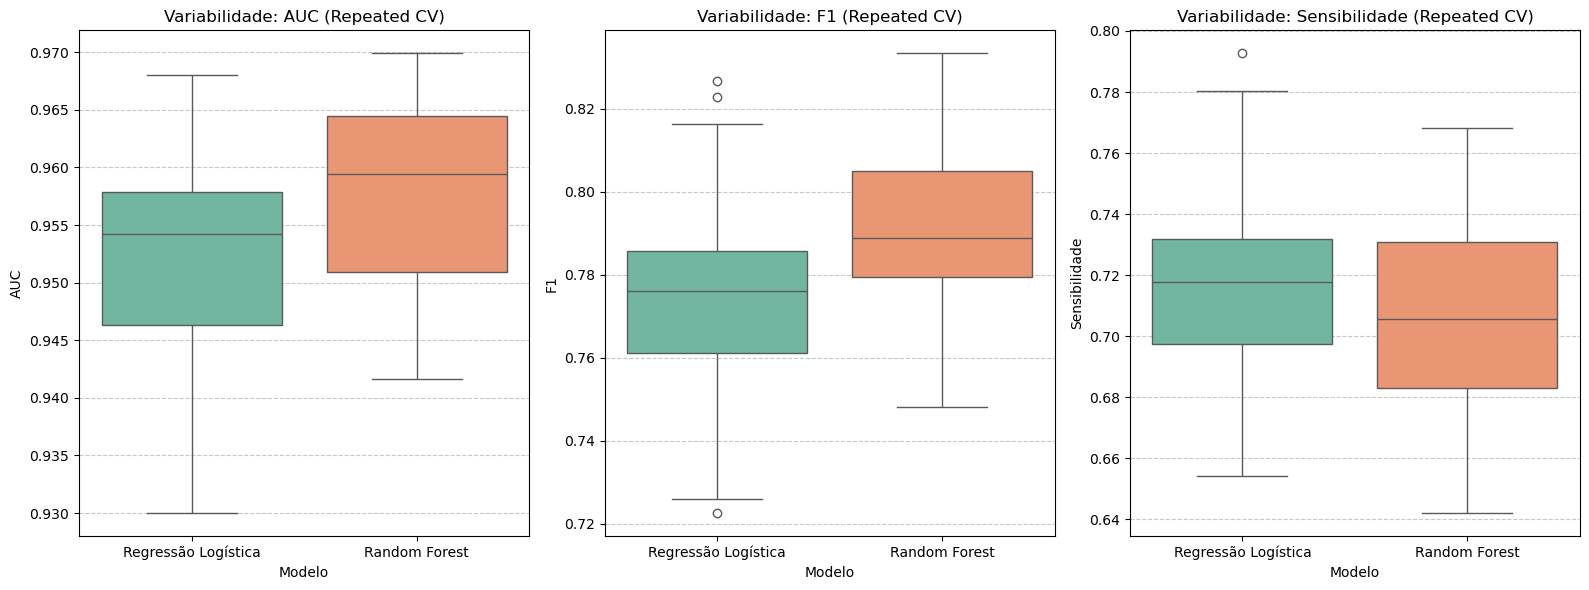

In [22]:
# Gráficos e tabelas

# Tabela de Comparação
df_comparacao = pd.DataFrame(resultados_finais, columns=['Modelo', 'Técnica', 'AUC', 'F1-Score', 'Sensibilidade'])
print("\n ----- TABELA COMPARATIVA FINAL -----")
display(df_comparacao.sort_values(by=['Técnica', 'Modelo']))

# Boxplots
df_box = pd.DataFrame(dados_boxplot)
plt.figure(figsize=(16, 6))

for idx, metrica in enumerate(['AUC', 'F1', 'Sensibilidade']):
    plt.subplot(1, 3, idx+1)
    sns.boxplot(x='Modelo', y=metrica, data=df_box, palette='Set2')
    plt.title(f'Variabilidade: {metrica} (Repeated CV)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

####  Análise da Tabela Comparativa

**Hold-Out (70/30):**
- AUC elevado (>0.90) indica excelente capacidade discriminativa entre as duas classes;
- F1-Score (~0.79) reflete equilíbrio entre precisão e recall, adequado para dataset desbalanceado;
- Sensibilidade (~70%) significa que o modelo identifica corretamente ~7 em 10 equipas qualificadas;

**Stratified K-Fold (k=10):**
- Resultados similares ao Hold-Out confirmam que o desempenho não é fruto de uma divisão aleatória favorável;
- Menor variabilidade entre os 10 folds demonstra robustez do modelo;
- A estratificação garante distribuição equilibrada das classes em cada fold, evitando enviesamento;

**Repeated K-Fold:**
- Convergência para valores ~0.79 (F1) após múltiplas repetições reforça confiabilidade estatística;
- Repetições adicionais reduzem o risco de bias amostral;
- Estabilidade de resultados indica que o modelo generaliza bem em diferentes subconjuntos.


#### Análise do Boxplot

**Dispersão de valores:**
- **Random Forest**: Maior consistência e desempenho ligeiramente superior;
- **Regressão Logística**: Maior variabilidade entre folds mas mais conservador.


Inicialmente, o modelo apresentou métricas de desempenho perfeitas (=1). Tecnicamente, este resultado não indicava uma aprendizagem, mas sim a presença de Data Leakage, uma vez que as variáveis continham informações sobre o target, incluídas inadvertidamente no conjunto de treino, tal como acontece no artigo estudado. No contexto deste dataset, o modelo via diretamente o resultado, em vez de inferir padrões a partir das estatísticas de jogo. Após a devida segregação das variáveis, as métricas passaram a refletir a capacidade real de generalização dos modelos, permitindo uma análise fidedigna da variabilidade, uma vez que o algoritmo começou a identificar as correlações entre a eficiência estatística das equipas e a sua probabilidade real de qualificação.

O Random Forest apresentou melhor desempenho médio nas métricas AUC e F1-Score, demonstrando maior capacidade preditiva. Contudo, a Regressão Logística revelou maior estabilidade entre folds, apresentando menor variabilidade nos resultados. As técnicas estratificadas produziram resultados mais consistentes devido ao balanceamento das classes em cada fold.
  

Stratified K-Fold (k=10): A utilização da estratificação foi crucial devido ao desequilíbrio das classes (existem significativamente mais equipas que não se qualificam do que equipas que avançam). Os resultados demonstram que o modelo é robusto em diferentes subconjuntos de dados.

Repeated Stratified K-Fold: A convergência para o mesmo valor após múltiplas repetições reforça a fiabilidade estatística do modelo, indicando baixa variância e confirmando que o desempenho não é fruto de uma divisão aleatória favorável (bias de amostragem).



O valor de AUC próximo de 1 demonstra que o classificador possui uma excelente capacidade de distinguir entre os perfis estatísticos de equipas qualificadas e não qualificadas. Esta métrica sugere que as variáveis independentes selecionadas (como eficiência ofensiva e defensiva) são preditores altamente significativos da performance das equipas. Já o F1-Score de aproximadamente 0.79, dado o desequilíbrio inerente às classes do dataset, valida a harmonia entre a precisão e a capacidade de recuperação do modelo. Este resultado indica que o algoritmo é conservador o suficiente para evitar um volume excessivo de falsos positivos, mantendo uma taxa de assertividade elevada. Quanto à sensibilidade, mostra que o modelo identifica a maioria das equipas que atingem a POSTSEASON. A margem residual de erro é atribuída à natureza estocástica do desporto universitário, onde equipas com métricas de época regular inferiores podem garantir o apuramento através de vagas automáticas, fenómeno que ultrapassa a capacidade puramente estatística de previsão.

Resumidamente, o modelo atual demonstra uma elevada capacidade preditiva, sendo capaz de distinguir com rigor o perfil estatístico de uma equipa de qualificada face a uma equipa de nível regional, fundamentando as suas decisões em métricas de eficiência e não em metadados de classificação.